In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
import zipfile

zip_ref = zipfile.ZipFile('archive.zip','r')
zip_ref.extractall('/content/bone_dataset')
zip_ref.close()

In [6]:
import os

print(os.listdir('/content/bone_dataset'))

['test', 'train', 'val']


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/bone_dataset/train'
val_dir = '/content/bone_dataset/val'
test_dir = '/content/bone_dataset/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 8863 images belonging to 2 classes.
Found 895 images belonging to 2 classes.
Found 399 images belonging to 2 classes.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 125s 423ms/step - accuracy: 0.5870 - loss: 0.6649 - val_accuracy: 0.5888 - val_loss: 0.6078
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 111s 402ms/step - accuracy: 0.6321 - loss: 0.6174 - val_accuracy: 0.6570 - val_loss: 0.5868
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 110s 397ms/step - accuracy: 0.6787 - loss: 0.5698 - val_accuracy: 0.7084 - val_loss: 0.5242
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 113s 407ms/step - accuracy: 0.7361 - loss: 0.5052 - val_accuracy: 0.8089 - val_loss: 0.4057
Epoch 5/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 112s 403ms/step - accuracy: 0.7818 - loss: 0.4375 - val_accuracy: 0.8045 - val_loss: 0.4331
Epoch 6/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 111s 400ms/step - accuracy: 0.8132 - loss: 0.3850 - val_accuracy: 0.8034 - val_loss: 0.3658
Epoch 7/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 110s 397ms/step - accuracy: 0.8501 - loss: 0.3288 - val_accuracy: 0.7989 - val_loss: 0.3651
Epoch 8/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 111s 400ms/step - accuracy: 0.8753 -

In [10]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_generator)

print("CNN Accuracy:", cnn_acc)
print("CNN Loss:", cnn_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.8997 - loss: 0.2381
CNN Accuracy: 0.8997493982315063
CNN Loss: 0.23809906840324402


In [11]:
predictions = cnn_model.predict(test_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense

In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [15]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
mobilenet_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 145s 458ms/step - accuracy: 0.7748 - loss: 0.4674 - val_accuracy: 0.7911 - val_loss: 0.4195
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 106s 381ms/step - accuracy: 0.8842 - loss: 0.2840 - val_accuracy: 0.8335 - val_loss: 0.3588
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 106s 381ms/step - accuracy: 0.9225 - loss: 0.1985 - val_accuracy: 0.8246 - val_loss: 0.4138
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 106s 382ms/step - accuracy: 0.9514 - loss: 0.1387 - val_accuracy: 0.8358 - val_loss: 0.3991
Epoch 5/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 108s 391ms/step - accuracy: 0.9558 - loss: 0.1191 - val_accuracy: 0.8279 - val_loss: 0.4712
Epoch 6/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 105s 381ms/step - accuracy: 0.9684 - loss: 0.0909 - val_accuracy: 0.8034 - val_loss: 0.5523
Epoch 7/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 105s 377ms/step - accuracy: 0.9733 - loss: 0.0804 - val_accuracy: 0.8302 - val_loss: 0.4947
Epoch 8/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 107s 387ms/step - accuracy: 0.9807 -

In [18]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_generator)

print("MobileNet Accuracy:", mobile_acc)
print("MobileNet Loss:", mobile_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 972ms/step - accuracy: 0.9599 - loss: 0.1274
MobileNet Accuracy: 0.9598997235298157
MobileNet Loss: 0.12738929688930511


In [19]:
from sklearn.metrics import classification_report
import numpy as np

pred = cnn_model.predict(test_generator)
pred = (pred > 0.5).astype(int)

print(classification_report(
    test_generator.classes,
    pred
))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step 
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       199
           1       0.86      0.95      0.90       200

    accuracy                           0.90       399
   macro avg       0.90      0.90      0.90       399
weighted avg       0.90      0.90      0.90       399



In [20]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9599 - loss: 0.1274


In [21]:
pred_mobile = mobilenet_model.predict(test_generator)
pred_mobile = (pred_mobile > 0.5).astype(int)

print(classification_report(
    test_generator.classes,
    pred_mobile
))

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       199
           1       0.97      0.95      0.96       200

    accuracy                           0.96       399
   macro avg       0.96      0.96      0.96       399
weighted avg       0.96      0.96      0.96       399



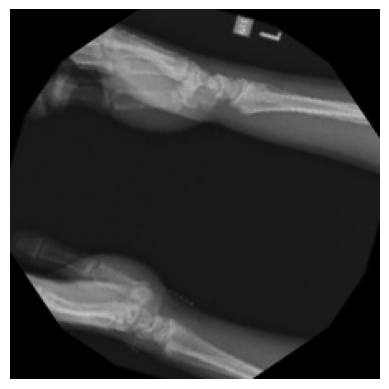

In [22]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

fractured_path = "/content/bone_dataset/train/fractured"

img_name = os.listdir(fractured_path)[0]

img = image.load_img(
    os.path.join(fractured_path,img_name)
)

plt.imshow(img)
plt.axis('off')
plt.show()

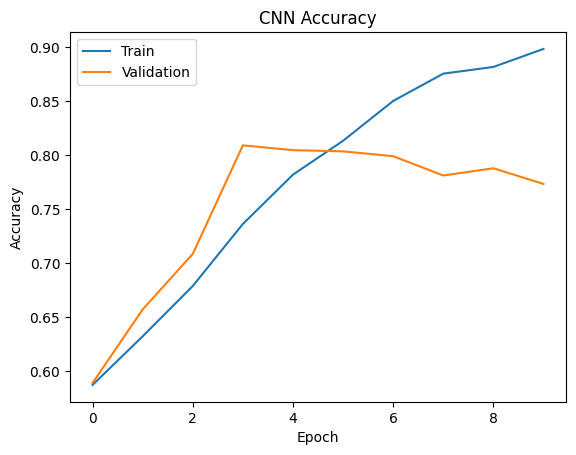

In [23]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title('CNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

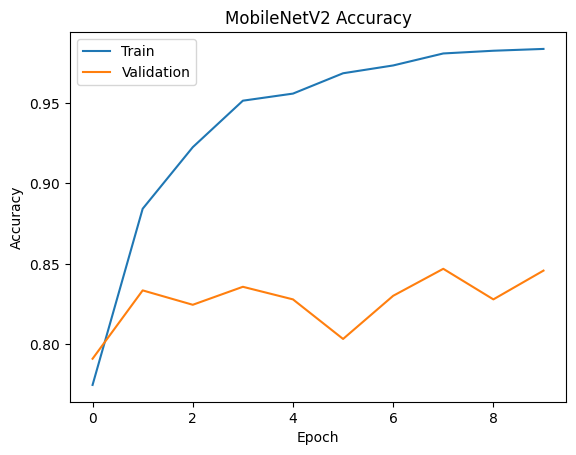

In [25]:
plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

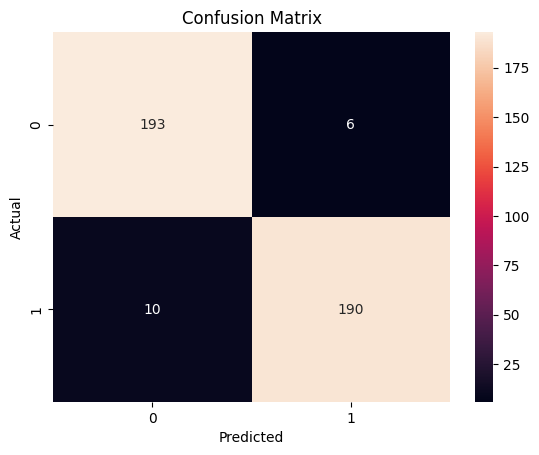

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    test_generator.classes,
    pred_mobile
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

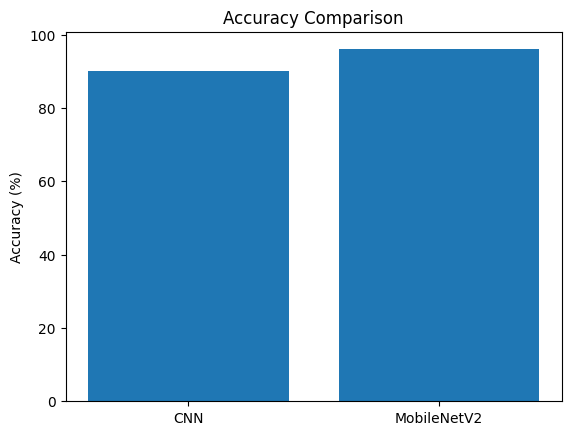

In [28]:
import matplotlib.pyplot as plt

models = ['CNN','MobileNetV2']
accuracy = [89.97,95.99]

plt.bar(models, accuracy)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison')
plt.show()